Titanic_EDA

In [1]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train.csv



--- FIRST 5 ROWS ---
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.05

/tmp/ipykernel_26197/4048681594.py:43: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_26197/4048681594.py:46: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

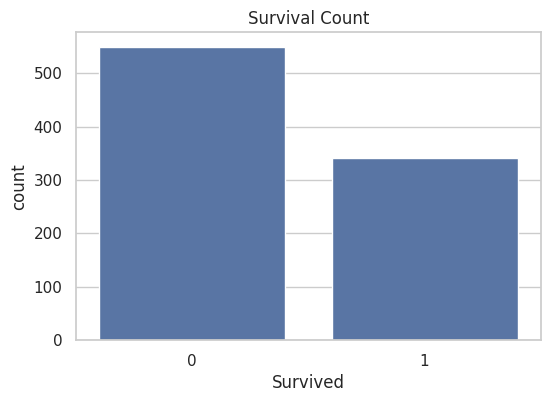

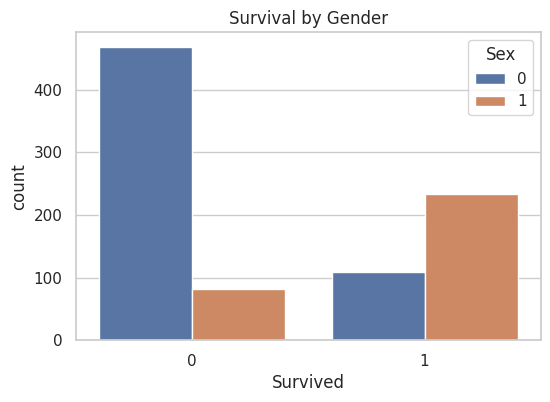

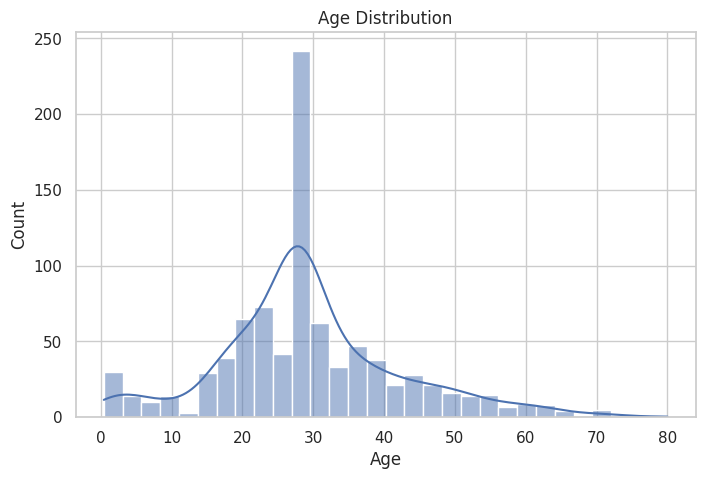

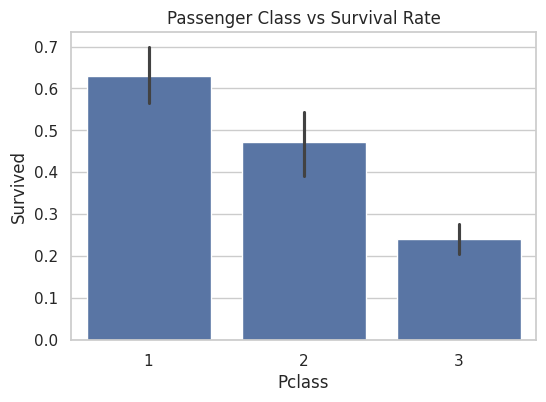


================ FINAL CONCLUSION ================

1. Majority of passengers did not survive the disaster.
2. Female passengers had a significantly higher survival rate.
3. Passenger class strongly influenced survival chances.
4. Age distribution shows most passengers were young adults.
5. Higher fare and upper class passengers had better survival probability.

Overall, socio-economic status played a major role in survival outcomes.



In [3]:
# =========================================
# TITANIC DATASET - EXPLORATORY DATA ANALYSIS
# =========================================

# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# ==============================
# 2. LOAD DATASET
# ==============================
# Download from Kaggle and keep CSV in same folder
df = pd.read_csv("train.csv")

# ==============================
# 3. BASIC INFORMATION
# ==============================
print("\n--- FIRST 5 ROWS ---")
print(df.head())

print("\n--- INFO ---")
print(df.info())

print("\n--- SUMMARY STATISTICS ---")
print(df.describe())

print("\n--- MISSING VALUES ---")
print(df.isnull().sum())

# ==============================
# 4. DATA CLEANING
# ==============================
# Drop duplicates
df.drop_duplicates(inplace=True)

# Fill missing Age with median
df['Age'].fillna(df['Age'].median(), inplace=True)

# Fill Embarked with mode
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Drop Cabin (too many missing values)
df.drop(columns=['Cabin'], inplace=True)

print("\n--- AFTER CLEANING ---")
print(df.isnull().sum())

# ==============================
# 5. DATA PREPROCESSING
# ==============================
# Encode categorical variables
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

print("\n--- AFTER PREPROCESSING ---")
print(df.head())

# ==============================
# 6. DATA VISUALIZATION
# ==============================

# ------------------------------
# GRAPH 1: SURVIVAL COUNT
# ------------------------------
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=df)
plt.title("Survival Count")

# Observation:
# More passengers did not survive compared to survivors.
plt.show()

# ------------------------------
# GRAPH 2: GENDER VS SURVIVAL
# ------------------------------
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', hue='Sex', data=df)
plt.title("Survival by Gender")

# Observation:
# Female passengers had higher survival rate than males.
plt.show()

# ------------------------------
# GRAPH 3: AGE DISTRIBUTION
# ------------------------------
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Age Distribution")

# Observation:
# Most passengers are between 20 and 40 years old.
plt.show()

# ------------------------------
# GRAPH 4: CLASS VS SURVIVAL
# ------------------------------
plt.figure(figsize=(6,4))
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title("Passenger Class vs Survival Rate")

# Observation:
# 1st class passengers had higher survival rate.
plt.show()

# ==============================
# 7. FINAL CONCLUSION
# ==============================

print("\n================ FINAL CONCLUSION ================")
print("""
1. Majority of passengers did not survive the disaster.
2. Female passengers had a significantly higher survival rate.
3. Passenger class strongly influenced survival chances.
4. Age distribution shows most passengers were young adults.
5. Higher fare and upper class passengers had better survival probability.

Overall, socio-economic status played a major role in survival outcomes.
""")